R2 Score: 0.8523573745040398
Predicted Car Price: 8449.0


c:\Users\Sunil Kale\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


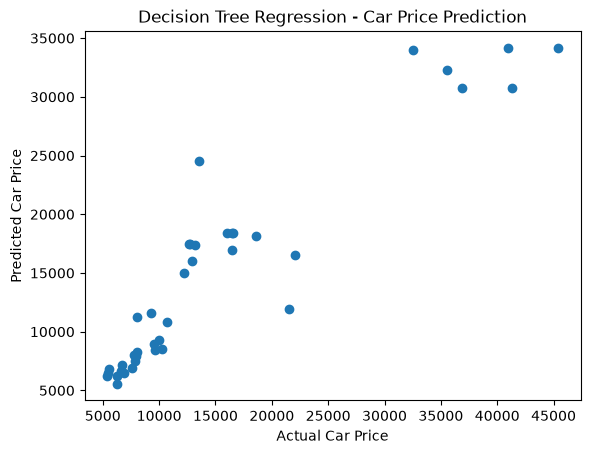

In [1]:
# 8. Implement Decision Tree Regression on Car Price Prediction
# Dataset: Car Price Prediction

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

# Load dataset
df = pd.read_csv("carprice.csv")

# Replace ? with NaN
df = df.replace("?", pd.NA)

# Select numerical features
features = [
    'horsepower',
    'engine-size',
    'curb-weight',
    'highway-mpg'
]

# Convert selected columns to numeric
for col in features + ['price']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Remove rows with missing values
df = df.dropna(subset=features + ['price'])

# Independent variables
X = df[features]

# Target variable
y = df['price']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create Decision Tree Regression model
model = DecisionTreeRegressor(random_state=42)

# Train model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# R2 Score
print("R2 Score:", r2_score(y_test, y_pred))

# New car prediction
new_car = [[
    120,    # horsepower
    130,    # engine-size
    2500,   # curb-weight
    27      # highway-mpg
]]

print("Predicted Car Price:", model.predict(new_car)[0])

# Visualization
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Car Price")
plt.ylabel("Predicted Car Price")
plt.title("Decision Tree Regression - Car Price Prediction")
plt.show()